# Проект: Исследование интернет-магазина «Подарочек»

* Автор: Филимонова Мария
* Дата: 16.03.2026

### Цели и задачи проекта

**Цель:** Провести комплексный анализ клиентской базы интернет-магазина подарков для выявления ключевых сегментов покупателей, оценки их поведения и разработки практических рекомендаций по повышению лояльности и увеличению выручки.

**Задачи:**

- Загрузить и объединить данные о продажах и описаниях товаров, выполнить первичный анализ структуры и качества данных.

- Провести предобработку данных: очистку от дубликатов, обработку пропусков, преобразование типов, удаление аномальных значений

- Исследовать распределения ключевых метрик и выявить зависимости от времени

- Провести RFM-сегментацию клиентов для выделения групп по давности последнего заказа, частоте и сумме покупок

- Оценить стабильность доли возвратных клиентов между кварталами и интерпретировать результаты.

### Описание данных

Основной датасет - `gift.csv`

- `entry_date` — дата записи;
- `order_id` — идентификационный номер заказа;
- `customer_id` — идентификационный номер клиента;
- `quantity` — количество;
- `price` — цена;
- `name_clust` — автоматически присвоенная группа записи на основе названия;
- `entry_id` — идентификационный номер записи;
- `country_id` — идентификационный номер страны.

Текстовое описание записей - `gift_entry`

- `entry_id` — идентификационный номер записи;
- `entry` — запись.

### Содержимое проекта

1. Получение, осмотр и объединение данных
2. Предобработка и начало исследовательского анализа
3. Расчёт метрик
4. RFM-сегментация клиентов
5. Проверка статистических гипотез
6. Итоговый вывод

## 1. Получение, осмотр и объединение данных

In [1]:
# Импортируем библиотеки
import pandas as pd
from datetime import datetime
from scipy.stats import chi2_contingency, mannwhitneyu

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### 1.1. Загрузка данных

In [2]:
# Выгружаем данные в переменную gift
try:
    gift = pd.read_csv('/datasets/gift.csv')
except FileNotFoundError:
    gift = pd.read_csv('C:/Users/Huawei/OneDrive/Рабочий стол/Проекты/Исследование интернет-магазина Подарочек/gift.csv')

In [3]:
# Выгружаем данные в переменную gift_entry
try:
    gift_entry = pd.read_csv('https://code.s3.yandex.net/python-for-analytics/gift_entry.csv', sep = ';')
except FileNotFoundError:
    gift_entry = pd.read_csv('C:/Users/Huawei/OneDrive/Рабочий стол/Проекты/Исследование интернет-магазина Подарочек/gift_entry.csv', sep = ';')

### 1.2. Вывод общей информации о датафреймах 

Познакомимся с данными датасета `gift.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [4]:
# Выводим первые строки датафрейма на экран
gift.head()

,entry_date,order_id,customer_id,quantity,price,name_clust,entry_id,country_id
0,12/01/2018 08:26,3031,2150,6,339,740,891,28
1,12/01/2018 08:26,3031,2150,8,275,132,1596,28
2,12/01/2018 08:26,3031,2150,6,339,197,166,28
3,12/01/2018 08:26,3031,2150,2,765,767,1810,28
4,12/01/2018 08:26,3031,2150,6,425,383,2585,28


In [5]:
# Выводим информацию о датафрейме
gift.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356940 entries, 0 to 356939
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   entry_date   356940 non-null  object
 1   order_id     356940 non-null  int64 
 2   customer_id  356940 non-null  int64 
 3   quantity     356940 non-null  int64 
 4   price        356940 non-null  int64 
 5   name_clust   356940 non-null  int64 
 6   entry_id     356940 non-null  int64 
 7   country_id   356940 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 21.8+ MB


Датасет `gift.csv` содержит 8 столбцов и 356940 строк, в котором представлена информация о записях подарков

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов написаны в одном стиле (предположительнго в стиле snake case)

- Большинство представленных данных хранятся в типе данных `int64`, кроме столбца `entry_ate` - тип данных `object`

- Значения в столбцах `order_id`, `customer_id`, `quantity`, `entry_id` и `country_id` имеют тип данных `int64`, данный тип подходит

- Значения в столбце `entry_date` имеет тип `object`. Тип данных данного столбца необходимо преобразовать в тип даты и времени

- Значения в столбце `price` имеет тип `int64`. Тип необходимо преобразовать к типу `float64`


Теперь познакомимся с данными датасета `gift_entry.csv`.

In [6]:
# Выводим первые строки датафрейма на экран
gift_entry.head()

,entry_id,entry
0,0,NaN
1,1,10-цветная ручка Spaceboy
2,2,"12 карандашей, черепа"
3,3,"12 карандашей, высокий тюбик, лесной массив"
4,4,"12 карандашей, маленький тюбик с черепом"


In [7]:
# Выводим информацию о датафрейме
gift_entry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2917 entries, 0 to 2916
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   entry_id  2917 non-null   int64 
 1   entry     2916 non-null   object
dtypes: int64(1), object(1)
memory usage: 45.7+ KB


Датасет `gift_entry.csv` содержит 2 столбцов и 2917 строк, в котором представлена информация о текстовом описании товара или записи:

- Названия столбцов написаны в одном стиле (предположительнго в стиле snake case)

- Столбцы в данном датасете имеют корректные типы данных

### 1.3. Проверяем наличие пропусков в данных

In [8]:
# Выводим количество пропущенных строк в датафрейме
gift.isna().sum().sort_values(ascending=False)

entry_date     0
order_id       0
customer_id    0
quantity       0
price          0
name_clust     0
entry_id       0
country_id     0
dtype: int64

In [9]:
# Выводим количество пропущенных строк в датафрейме
gift_entry.isna().sum().sort_values(ascending=False)

entry       1
entry_id    0
dtype: int64

**Вывод:**

- Как видно из вывода, во всех столбцах отсутствуют пропуски

- Поскольку пропусков нет, заполнение не требуется. Данные полностью готовы к дальнейшему анализу без необходимости обработки отсутствующих значений.

### 1.4. Проверяем наличие дубликатов в данных

In [10]:
# Проверяем полные дубликаты в датафрейме gift
full_duplicates = gift.duplicated().sum()
print(f'Количество полностью дублирующихся строк: {full_duplicates}')

Количество полностью дублирующихся строк: 3573


In [11]:
# Проверяем полные дубликаты в датафрейме gift_entry
full_duplicates = gift_entry.duplicated().sum()
print(f'Количество полностью дублирующихся строк: {full_duplicates}')

Количество полностью дублирующихся строк: 0


**Вывод:**

- В датафрейме `gift` находится 3573 полных дубликатов. Полные дубликаты необходимо уалить

- В датафрейме `gift_entry` нет полных дубликатов

In [12]:
# Удалим полные дубликаты в датафрейме `gift`
gift = gift.drop_duplicates()

### 1.5. Типы данных

Необходимо изменить типы данных в датафрейме `gift` в столбцах `entry_date` и `price`

In [13]:
# Преобразуем столбец price в вещественный тип данных
gift['price'] = gift['price'].astype('float64')

In [14]:
# Преобразуем столбец entry_date в тип данных даты и времени
gift['entry_date'] = pd.to_datetime(gift['entry_date'], format="%d/%m/%Y %H:%M")

In [15]:
# Проверим типы данных после преобразования
gift.dtypes

entry_date     datetime64[ns]
order_id                int64
customer_id             int64
quantity                int64
price                 float64
name_clust              int64
entry_id                int64
country_id              int64
dtype: object

### 1.6. Проверка соответствия идентификационных номеров

In [16]:
# Создадим множеста с уникальными идентификационными номерами из датафреймов
gift_ids = set(gift['entry_id'])
entry_ids = set(gift_entry['entry_id'])

In [17]:
# Найдем расхождения
missing_in_entry = gift_ids - entry_ids   
missing_in_gift = entry_ids - gift_ids    

In [18]:
# вывод результатов
print(f'Уникальных entry_id в gift: {len(gift_ids)}')
print(f'Уникальных entry_id в gift_entry: {len(entry_ids)}')
print(f'Количество entry_id из gift, отсутствующих в справочнике: {len(missing_in_entry)}')
print(f'Количество entry_id из справочника, не используемых в gift: {len(missing_in_gift)}')

Уникальных entry_id в gift: 2917
Уникальных entry_id в gift_entry: 2917
Количество entry_id из gift, отсутствующих в справочнике: 0
Количество entry_id из справочника, не используемых в gift: 0


**Вывод:**

- Количество уникальных идентификаторов в обоих датафреймах одинаково - 2917

- Расхождения отсутсвуют

### 1.7. Объединение данных

In [19]:
# Объединяем
gift_merged = gift.merge(gift_entry, on='entry_id', how='left')

In [20]:
# Проверяем результат
gift_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353367 entries, 0 to 353366
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   entry_date   353367 non-null  datetime64[ns]
 1   order_id     353367 non-null  int64         
 2   customer_id  353367 non-null  int64         
 3   quantity     353367 non-null  int64         
 4   price        353367 non-null  float64       
 5   name_clust   353367 non-null  int64         
 6   entry_id     353367 non-null  int64         
 7   country_id   353367 non-null  int64         
 8   entry        351858 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(1)
memory usage: 24.3+ MB


In [21]:
# Выводим первые строки датафрейма
gift_merged.head()

,entry_date,order_id,customer_id,quantity,price,name_clust,entry_id,country_id,entry
0,2018-01-12 08:26:00,3031,2150,6,339.0,740,891,28,белый металлический фонарь
1,2018-01-12 08:26:00,3031,2150,8,275.0,132,1596,28,кремовая вешалка в форме сердечек Купидона
2,2018-01-12 08:26:00,3031,2150,6,339.0,197,166,28,Вязаная грелка с флагом Союза
3,2018-01-12 08:26:00,3031,2150,2,765.0,767,1810,28,набор 7 скворечников для бабушек
4,2018-01-12 08:26:00,3031,2150,6,425.0,383,2585,28,стеклянный матовый держатель в форме звезды


### 1.8. промежуточные выводы

В результате предобработки данных были выполнены следующие действия:

- Изучены данные на пропуски - пропуски в данных не были выявлены

- Удалены полные дубликаты из датафрейма `gift`

- Скорректированы типы данных в датафрейме `gift`, а именно типы данных столбцов `entry_date` и `price`

- Проведена проверка соответствия идентификаторов

- Проведено объединение данных

## 2. Предобработка и начало исследовательского анализа

### 2.1. Анализ выбросов и аномальных значений в столбцах `price` и `quantity`

In [22]:
# Вывод статистики
print('Статистика по столбцам price и quantity')
print(gift_merged[['price', 'quantity']].describe().round(2))

Статистика по столбцам price и quantity
            price   quantity
count   353367.00  353367.00
mean       401.68      10.22
std       5084.62     147.51
min   -1106206.00   -9600.00
25%        125.00       1.00
50%        208.00       3.00
75%        413.00      10.00
max    1354133.00   80995.00


**Обработка выбросов и аномальных значений столбца `price`**

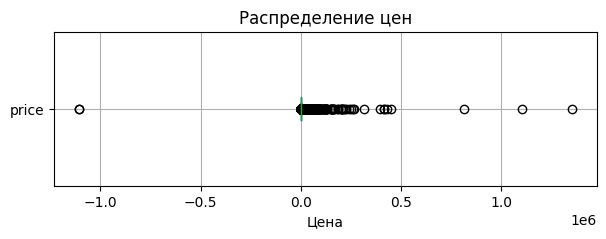

In [23]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце price
gift_merged.boxplot(column='price', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение цен')
plt.xlabel('Цена')

# Выводим график
plt.show()

In [24]:
# Вычисляем квартили
Q1 = gift_merged['price'].quantile(0.25)
Q3 = gift_merged['price'].quantile(0.75)

# Вычисляем межквартильный размах
IQR = Q3 - Q1

# Определяем границы выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Фильтруем выбросы
outliers = gift_merged[(gift_merged['price'] < lower_bound) | (gift_merged['price'] > upper_bound)]

# Выводим результат
print(f'Количество выбросов: {len(outliers)}')

Количество выбросов: 26875


**Вывод:**

Из визуализированнных данных и расчета по методу межквартильного размаха (IQR) можно прийти к выводу

- выявлены значения цен с отрицательными значениями

- также были выявлены чрезвычайно высокие значения

- большое стандартное отклонение (5084) подтверждает наличие выбросов

**Решение:**

- удаление отрицательных и нулевых цен

- обработка выбросов с помощью процентилей

In [25]:
# Удаляем отрицательные цены 
gift_merged = gift_merged[gift_merged['price'] >= 0]

# Удаляем нулевую цену
gift_merged = gift_merged[gift_merged['price'] > 0]

# Обработаем выбросы с помощью процентилей
price_upper = gift_merged['price'].quantile(0.99)
gift_merged = gift_merged[gift_merged['price'] <= price_upper]

Выведем boxplot после обработки и удалении выбросов

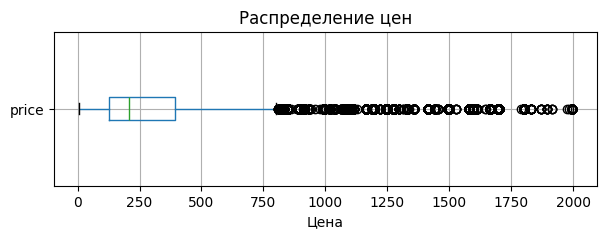

In [26]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце price
gift_merged.boxplot(column='price', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение цен')
plt.xlabel('Цена')

# Выводим график
plt.show()

**Обработка выбросов и аномальных значений столбца `quantity`**

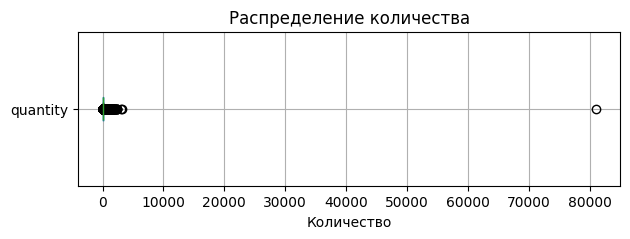

In [27]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце quantity
gift_merged.boxplot(column='quantity', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества')
plt.xlabel('Количество')

# Выводим график
plt.show()

In [28]:
# Вычисляем квартили
Q1 = gift_merged['quantity'].quantile(0.25)
Q3 = gift_merged['quantity'].quantile(0.75)

# Вычисляем межквартильный размах
IQR = Q3 - Q1

# Определяем границы выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Фильтруем выбросы
outliers = gift_merged[(gift_merged['quantity'] < lower_bound) | (gift_merged['quantity'] > upper_bound)]

# Выводи результат
print(f'Количество выбросов: {len(outliers)}')

Количество выбросов: 38452


**Вывод:**

Из визуализированнных данных и расчета по методу межквартильного размаха (IQR) можно прийти к выводу

- выявлены значения количества с отрицательными значениями

- также было выявлено чрезвычайно высокое значение

- большое стандартное отклонение (147) подтверждает наличие выбросов

**Решение:** 

- удаление отрицательных и нулевых значений количества

- обработка выбросов с помощью процентилей

In [29]:
# Удаляем отрицательное количество 
gift_merged = gift_merged[gift_merged['quantity'] >= 0]

# Удаляем нулевое количество, если есть 
gift_merged = gift_merged[gift_merged['quantity'] > 0]

# Обработаем выбросы с помощью процентилей
price_upper = gift_merged['quantity'].quantile(0.95)
gift_merged = gift_merged[gift_merged['quantity'] <= price_upper]

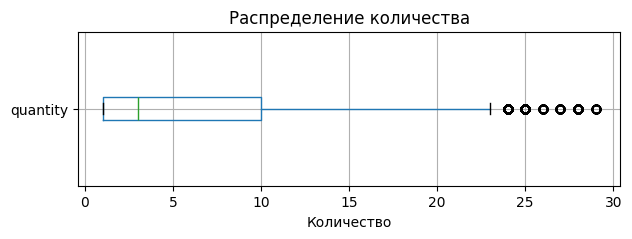

In [30]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце quantity
gift_merged.boxplot(column='quantity', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества')
plt.xlabel('Количество')

# Выводим график
plt.show()

**Расчет суммы стоимости каждой товарной позиции**

In [31]:
# Расчет суммы стоимости каждой строки
gift_merged['total_price'] = gift_merged['price'] * gift_merged['quantity']

In [32]:
# Группируем и вычисляем сумму выручки и общее количество
item_revenue = gift_merged.groupby('entry_id').agg(total_quantity = ('quantity', 'sum'),
                                    total_price=('total_price', 'sum')).reset_index().sort_values(by='total_price', ascending=False)

# Выводим результат
print('Топ-10 товаров по общей выручке')
print(item_revenue.head(10))

Топ-10 товаров по общей выручке
      entry_id  total_quantity  total_price
2101      2223            7088    8399609.0
2131      2254            8277    4682445.0
2130      2253            2396    4133176.0
853        957           13792    3176660.0
2156      2280            5245    2908631.0
2753      2883            4521    2518450.0
1752      1869            4597    2483427.0
1069      1175            4527    2190893.0
2473      2601           10602    2060269.0
692        793            3984    2049376.0


### 2.2. Изучение столбцов `order_id`, `customer_id`, `name_clust`, `entry_id` и `country_id`

**Анализ столбца `order_id`**

In [33]:
# Выводим статистику
print('Статистика по order_id:')
print(f"Уникальных order_id: {gift_merged['order_id'].nunique()}")
print(f"Доля заказов с отрицательным ID: {(gift_merged['order_id'] < 0).mean():.2%}")

# Распределение числа позиций в заказе
order_sizes = gift_merged.groupby('order_id').size()
print('\nРаспределение количества позиций в заказе:')
print(order_sizes.describe().round(2))

Статистика по order_id:
Уникальных order_id: 17601
Доля заказов с отрицательным ID: 0.00%

Распределение количества позиций в заказе:
count    17601.00
mean        18.78
std         33.44
min          1.00
25%          5.00
50%         11.00
75%         20.00
max        739.00
dtype: float64


**Вывод:**

- Количество уникальных заказов составляет 17600

- Число позиций варьируется от 1 до 735, при среднем значении 18,8 и медиане 11. Столь высокие показатели (особенно максимум 735) свидетельствуют о наличии:

    - Крупных оптовых заказов (возможно, бизнес-клиенты или праздничные корпоративные закупки);

    - Потенциальных выбросов или ошибок данных

**Анализ столбца `customer_id`**

In [34]:
# Выводим статистику
print('Статистика по customer_id:')
print(f"Уникальных customer_id: {gift_merged['customer_id'].nunique()}")
print(f"Доля клиентов с отрицательным ID: {(gift_merged['customer_id'] < 0).mean():.2%}")

# Количество заказов на клиента
customer_orders = gift_merged.groupby('customer_id')['order_id'].nunique()
print('\nСтатистика по числу заказов на клиента:')
print(customer_orders.describe().round(2))

Статистика по customer_id:
Уникальных customer_id: 4149
Доля клиентов с отрицательным ID: 26.27%

Статистика по числу заказов на клиента:
count    4149.00
mean        4.24
std        20.98
min         1.00
25%         1.00
50%         2.00
75%         4.00
max      1294.00
Name: order_id, dtype: float64


**Вывод:**

- Уникальных клиентов насчитывается 4149

- Доля клиентов с отрицательным идентификатором составляет 26,24%. Это означает, что более четверти всех уникальных customer_id являются отрицательными числами. Такая ситуация неприемлема для реальных данных и свидетельствует о серьёзных проблемах с их качеством

- Число заказов на одного клиента варьируется от 1 до 1294, при среднем значении 4,24, что выше медианы (2) из-за выбросов

- Стандартное отклонение также велико (20,98), что подтверждает наличие выбросов

**Решение:**

- Удалить данные с отрицательными значениями `customer_id`. Поскольку такие идентификаторы не могут соответствовать реальным клиентам, их присутствие исказит любой анализ, связанный с поведением клиентов

In [35]:
# Удаляем отрицательные значения
gift_merged = gift_merged[gift_merged['customer_id'] > 0]

**Анализ столбца `name_clust`**

In [36]:
# Выводим статистику
print('Статистика по name_clust:')
print(f"Уникальных значений name_clust: {gift_merged['name_clust'].nunique()}")
print('\nТоп-10 наиболее частых кластеров:')
print(gift_merged['name_clust'].value_counts().head(10))

Статистика по name_clust:
Уникальных значений name_clust: 889

Топ-10 наиболее частых кластеров:
name_clust
427    4742
516    3363
415    3267
223    2646
852    2472
898    2093
726    1885
87     1858
102    1696
822    1554
Name: count, dtype: int64


**Вывод:**

- Общее количество уникальных кластеров составляет 889

- Распределение частот кластеров крайне неравномерно:

    - Самый популярный кластер (код 427) встречается 4742 раза

    - Второй по популярности кластер (516) – 3363 вхождения, третий (415) – 3267.

- Топ-10 кластеров суммарно охватывают примерно 26 500 записей (порядка 7–8% от общего объёма)

**Анализ столбца `entry_id`**

In [37]:
# Выводим статистику
print('Статистика по entry_id:')
print(f"Уникальных entry_id: {gift_merged['entry_id'].nunique()}")
print(f'Всего записей о продажах: {len(gift_merged)}')

# Частота встречаемости товаров
item_freq = gift_merged['entry_id'].value_counts()
print('\nСтатистика по частоте товаров:')
print(item_freq.describe().round(2))

Статистика по entry_id:
Уникальных entry_id: 2669
Всего записей о продажах: 243686

Статистика по частоте товаров:
count    2669.00
mean       91.30
std       137.79
min         1.00
25%        10.00
50%        40.00
75%       115.00
max      1539.00
Name: count, dtype: float64


**Вывод:**

- Количество уникальных товаров составляет 2669

- Общее количество записей о продажах – 243 686 строк

- Распределение частоты продаж крайне неравномерно:

    - Средняя частота – 91 раз на товар, но стандартное отклонение (138) говорит о сильном разбросе.

    - Минимальная частота – 1 (есть товары, проданные всего один раз).

    - Максимальная частота – 1539 раз (товар-лидер).

**Анализ столбца `country_id`**

In [38]:
# Выводим статистику
print('Статистика по country_id:')
print(f"Уникальных country_id: {gift_merged['country_id'].nunique()}")

print(f"\nДоля записей с отрицательным country_id: {(gift_merged['country_id'] < 0).mean():.2%}")
print(f"Доля записей с country_id = 0: {(gift_merged['country_id'] == 0).mean():.2%}")

top_countries = gift_merged['country_id'].value_counts().head(10)
print('\nТоп-10 стран по числу записей:')
print(top_countries)

Статистика по country_id:
Уникальных country_id: 29

Доля записей с отрицательным country_id: 0.00%
Доля записей с country_id = 0: 0.16%

Топ-10 стран по числу записей:
country_id
28    222578
6       6275
5       5793
23      1587
3       1474
25      1166
19       993
17       619
16       568
11       498
Name: count, dtype: int64


**Вывод:**

- Общее количество уникальных стран составляет 29, что указывает на достаточно широкую географию продаж

- Отрицательные идентификаторы стран отсутствуют (0%)

- Доля записей с country_id = 0 равна 0,16%. Такие записи могут соответствовать незаполненным или неизвестным странам.

- Лидирующая страна с кодом 28 охватывает 222 578 записей

### 2.3. Изучение полноты данных

In [39]:
# Извлекаем только дату
gift_merged['date'] = gift_merged['entry_date'].dt.date

# Преобразуем entry_date в формат datetime
gift_merged['year_month'] = pd.to_datetime(gift_merged['entry_date']).dt.strftime('%Y-%m')

In [40]:
# Группируем данные по месяцам и переименовываем столбцы
monthly_sales_days = gift_merged.groupby('year_month')['date'].nunique().reset_index()
monthly_sales_days.columns = ['year_month', 'days_with_sales']

In [41]:
# Выводим полученный датафрейм
monthly_sales_days

,year_month,days_with_sales
0,2018-01,1
1,2018-02,1
2,2018-03,1
3,2018-05,1
4,2018-06,1
5,2018-07,1
6,2018-08,1
7,2018-09,1
8,2018-10,1
9,2018-12,11


In [42]:
# Функция для расчёта общего количества дней в месяце
def total_days_in_month(year_month_str):

    # Разбиваем строки на год и месяц
    year, month = map(int, year_month_str.split('-'))

    # Определяем первый день следующего месяца
    if month == 12:
        next_month = datetime(year + 1, 1, 1)
    else:
        next_month = datetime(year, month + 1, 1)
    
    # Определяем первый день текущего месяца
    first_day = datetime(year, month, 1)

    # Расчитываем количество дней в месяце
    return (next_month - first_day).days

In [43]:
# Добавляем колонку с общим количеством дней в каждом месяце
monthly_sales_days['total_days'] = monthly_sales_days['year_month'].apply(total_days_in_month)

# Рассчитываем дни без продаж
monthly_sales_days['days_without_sales'] = (monthly_sales_days['total_days'] - monthly_sales_days['days_with_sales'])

# Сортируем по дате
monthly_sales_days = monthly_sales_days.sort_values('year_month').reset_index(drop=True)

# Выводим результат
print('Количество дней без продаж по месяцам:')
print(monthly_sales_days[['year_month', 'days_without_sales']].to_string(index=False))

Количество дней без продаж по месяцам:
year_month  days_without_sales
   2018-01                  30
   2018-02                  27
   2018-03                  30
   2018-05                  30
   2018-06                  29
   2018-07                  30
   2018-08                  30
   2018-09                  29
   2018-10                  30
   2018-12                  20
   2019-01                   5
   2019-02                   6
   2019-03                   5
   2019-04                   8
   2019-05                   7
   2019-06                   3
   2019-07                   4
   2019-08                   6
   2019-09                   4
   2019-10                   5
   2019-11                   4
   2019-12                  23


**Вывод:**

Из полученной таблицы видно, что данные за 2018 год крайне разрежены: в каждом месяце от 20 до 30 дней без продаж, что означает, что продажи были лишь в единичные дни

Но в 2019 году картина другая:

- С января по ноябрь количество дней без продаж варьируется от 3 до 8. Это приемлемый уровень полноты

- Декабрь: опять большое количество дней без продаж (23 дня)

Таким образом, стоит выбрать 2019 год для дальнейшего анализа, при этом стоит исключить декабрь.

In [44]:
# Задаём границы периода
start_date = '2019-01-01'
end_date = '2019-11-30'

# Фильтруем датафрейм
gift_filtered = gift_merged[
    (gift_merged['entry_date'] >= start_date) & 
    (gift_merged['entry_date'] <= end_date)
].copy()

# Выводим результат
print(f'Размер исходного датафрейма: {len(gift_merged)}')
print(f'Размер после фильтрации: {len(gift_filtered)}')
print(f'Доля сохранённых записей: {len(gift_filtered)/len(gift_merged)*100:.1f}%')

Размер исходного датафрейма: 243686
Размер после фильтрации: 221470
Доля сохранённых записей: 90.9%


## 3. Расчёт метрик

### 3.1. Оценка количества заказов и количества уникальных поситителей по часам и дням недели

In [45]:
# Извлекаем час 
gift_filtered['hour'] = gift_filtered['entry_date'].dt.hour

# Извлекаем день недели
gift_filtered['weekday'] = gift_filtered['entry_date'].dt.weekday 

In [46]:
# Считаем количество заказов и уникальных покупателей по часам
hour_analys = gift_filtered.groupby('hour').agg(orders_count = ('order_id', 'count'),
                                                unique_customer = ('customer_id', 'nunique')).reset_index()

# Выводим результат
print('Анализ по часам')
print(hour_analys)

Анализ по часам
    hour  orders_count  unique_customer
0      6             1                1
1      7           112               17
2      8          4660              363
3      9         11724              748
4     10         20078             1066
5     11         27086             1119
6     12         40293             1428
7     13         36270             1370
8     14         30653             1213
9     15         26002             1093
10    16         13419              623
11    17          7515              343
12    18          1573              111
13    19          1729               77
14    20           355               12


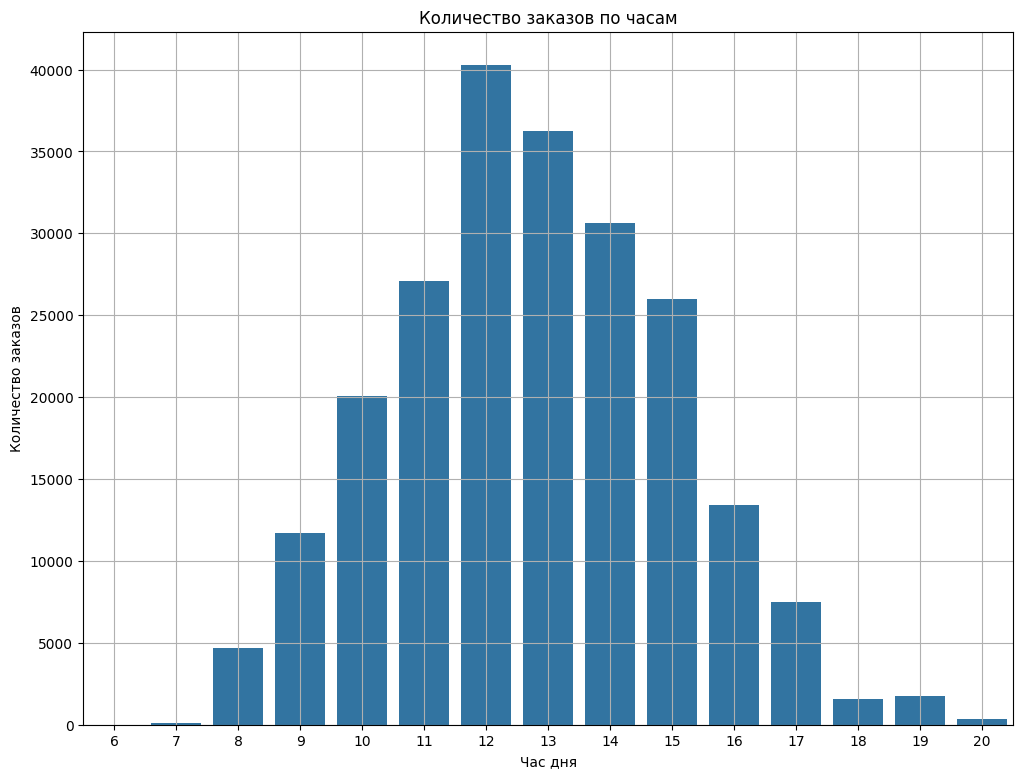

In [47]:
# Задаем размер графика
plt.figure(figsize = (12, 9))

# Строим столбчатую диаграмму
sns.barplot(data=hour_analys, x='hour', y='orders_count')

# Настраиваем оформление графика
plt.title('Количество заказов по часам')
plt.xlabel('Час дня')
plt.ylabel('Количество заказов')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

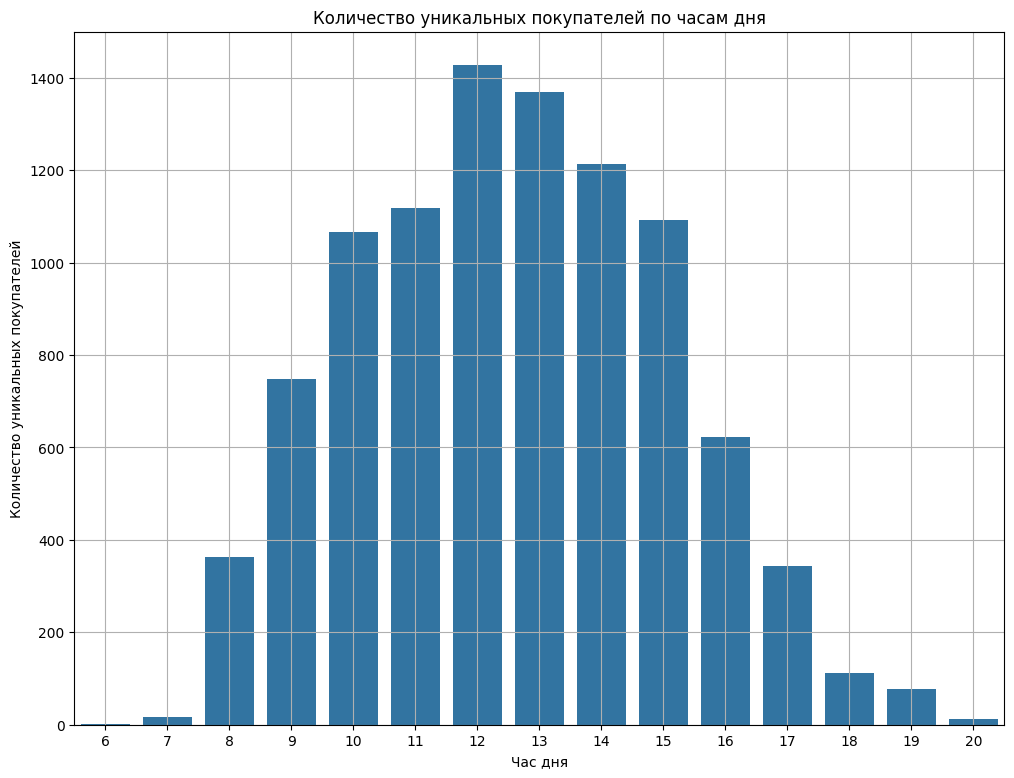

In [48]:
# Задаем размер графика
plt.figure(figsize = (12, 9))

# Строим столбчатую диаграмму
sns.barplot(data=hour_analys, x='hour', y='unique_customer')

# Настраиваем оформление графика
plt.title('Количество уникальных покупателей по часам дня')
plt.xlabel('Час дня')
plt.ylabel('Количество уникальных покупателей')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Дневной пик наблюдается в интервале с 10 до 14 часов

- После 14 часов активность постепенно снижается: к 16 часам число заказов падает до 13 419, а к 18 часам – до 1 573

- Вечерняя активность резко падает после 18 часов: в 19 часов ещё 1 729 заказов, но в 20 часов – лишь 355

- Графики количества заказов и уникальных покупателей практически идентичны по форме, что указывает на прямую зависимость: рост числа покупателей влечёт пропорциональный рост числа заказов

In [49]:
# Количество заказов и уникальных покупателей по часам
weekday_analys = gift_filtered.groupby('weekday').agg(orders_count = ('order_id', 'count'),
                                                unique_customer = ('customer_id', 'nunique')).reset_index()

# Выводим результат
print('Анализ по дням недели (0 - понедельник, 6 - воскресенье)')
print(weekday_analys)

Анализ по дням недели (0 - понедельник, 6 - воскресенье)
   weekday  orders_count  unique_customer
0        0         31832             1396
1        1         12099              612
2        2         35340             1278
3        3         33813             1368
4        4         36792             1478
5        5         31097             1319
6        6         40497             1661


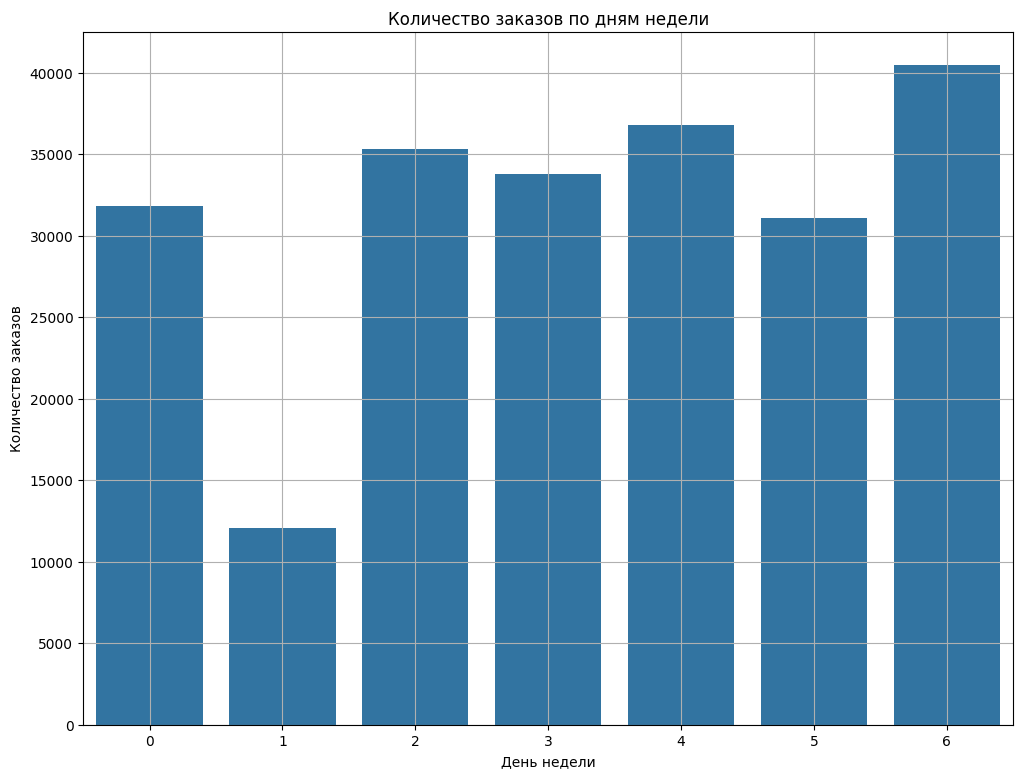

In [50]:
# Задаем размер графика
plt.figure(figsize = (12, 9))

# Строим столбчатую диаграмму
sns.barplot(data=weekday_analys, x='weekday', y='orders_count')

# Настраиваем оформление графика
plt.title('Количество заказов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

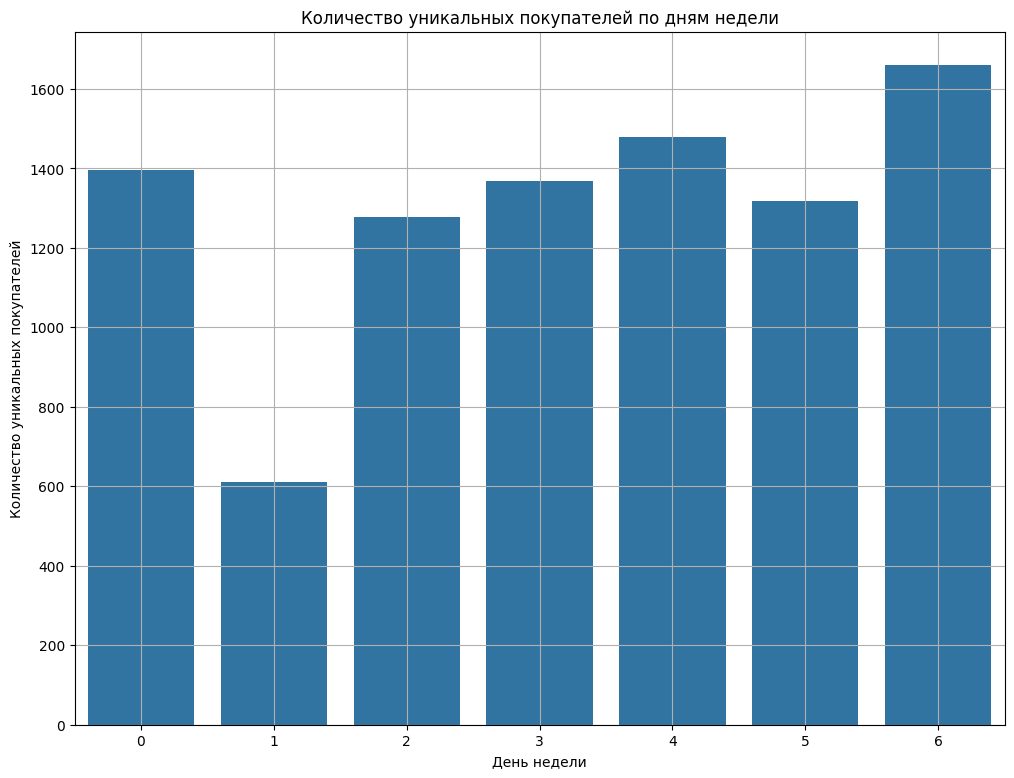

In [51]:
# Задаем размер графика
plt.figure(figsize = (12, 9))

# Строим столбчатую диаграмму
sns.barplot(data=weekday_analys, x='weekday', y='unique_customer')

# Настраиваем оформление графика
plt.title('Количество уникальных покупателей по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество уникальных покупателей')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Наибольшая активность приходится на воскресенье:

    - Количество заказов: 40 497

    - Уникальных покупателей: 1 661
    Это самый высокий показатель среди всех дней.

- Высокая активность также наблюдается в четверг: 36 792 заказа и 1 478 покупателей, а также в среду: 35 340 заказов и 1 278 покупателей

- Аномально низкая активность зафиксирована во вторник: всего 12 099 заказов и 612 покупателей. Это резко контрастирует с остальными днями

### 3.2. Расчет средней выручки с клиента в день и количества уникальных покупателей по месяцам

In [52]:
# Группируем данные по месяцам
monthly_stats = gift_filtered.groupby('year_month').agg(total_revenue=('total_price', 'sum'),
                                                        unique_customer = ('customer_id', 'nunique')).reset_index()

# Выводим результат
print('Анализ по месяцам')
print(monthly_stats)

Анализ по месяцам
   year_month  total_revenue  unique_customer
0     2019-01     21891957.0              814
1     2019-02     20003038.0              738
2     2019-03     22434872.0              886
3     2019-04     23008337.0              837
4     2019-05     26779987.0              939
5     2019-06     26436156.0              963
6     2019-07     26660637.0             1000
7     2019-08     25815962.0              897
8     2019-09     33550232.0             1115
9     2019-10     34002028.0             1168
10    2019-11     39899705.0             1350


In [53]:
# Функция для расчёта общего количества дней в месяце
def total_days_in_month(year_month_str):
    # Разбиваем строку на год и месяц
    year, month = map(int, year_month_str.split('-'))
    # Определяем первый день следующего месяца
    if month == 12:
        next_month = datetime(year + 1, 1, 1)
    else:
        next_month = datetime(year, month + 1, 1)
    # Определяем первый день текущего месяца
    first_day = datetime(year, month, 1)
    # Рассчитываем количество дней в месяце
    return (next_month - first_day).days

# Добавляем колонку с общим количеством дней в каждом месяце
# Преобразуем year_month в строку перед применением функции
monthly_stats['total_days'] = monthly_stats['year_month'].astype(str).apply(total_days_in_month)

In [54]:
# Рассчитываем средний доход на клиента в месяц с учётом количества дней
monthly_stats['avg_revenue'] = (monthly_stats['total_revenue'] / monthly_stats['unique_customer'] * monthly_stats['total_days']).round(2)

In [55]:
# Сортируем по дате (от старых к новым)
monthly_analysis = monthly_stats.sort_values('year_month').reset_index(drop=True)

In [56]:
# Выбираем нужные колонки для вывода
result = monthly_analysis[[
    'year_month',
    'unique_customer',
    'avg_revenue'
]]

print('Средняя выручка с клиента в день и количество уникальных покупателей по месяцам:')
print(result.to_string(index=False))

Средняя выручка с клиента в день и количество уникальных покупателей по месяцам:
year_month  unique_customer  avg_revenue
   2019-01              814    833723.18
   2019-02              738    758922.85
   2019-03              886    784967.30
   2019-04              837    824671.58
   2019-05              939    884110.33
   2019-06              963    823556.26
   2019-07             1000    826479.75
   2019-08              897    892190.44
   2019-09             1115    902696.83
   2019-10             1168    902451.09
   2019-11             1350    886660.11


**Вывод:**

- Рост клиентской базы: число уникальных покупателей за рассматриваемый период увеличилось с 814 в январе до 1350 в ноябре

- Выручка и количество покупателей демонстрируют устойчивый рост с сентября по ноябрь:

    - сентябрь: 33,6 млн у.е. и 1115 покупателей;

    - октябрь: 34,0 млн у.е. и 1168 покупателей;

    - ноябрь: 39,9 млн у.е. и 1350 покупателей.

Таким образом, вероятно наличие сезонности с пиком в конце года

### 3.3. Расчет стики-факторов

**Расчет стики-фактора для 2 и 3 кварталов 2019 года**

In [57]:
# Фильтруем данные за 2‑й и 3‑й кварталы 2019 года (апрель–сентябрь)
df_q2_q3 = gift_filtered[(gift_filtered['entry_date'] >= '2019-04-01') & (gift_filtered['entry_date'] <= '2019-09-30')].copy()

In [58]:
# Расчитаем MAU по месяцам
monthly_mau = df_q2_q3.groupby('year_month')['customer_id'].nunique().reset_index()
monthly_mau.columns = ['year_month', 'MAU']

# Выводим результат
print(monthly_mau)

  year_month   MAU
0    2019-04   837
1    2019-05   939
2    2019-06   963
3    2019-07  1000
4    2019-08   897
5    2019-09  1080


In [59]:
# Создаём колонку с датой без времени
df_q2_q3['date'] = df_q2_q3['entry_date'].dt.date

# Рассчитываем DAU по дням (уникальные покупатели в день)
daily_dau = df_q2_q3.groupby('date')['customer_id'].nunique().reset_index()
daily_dau.columns = ['date', 'DAU']

# Добавляем колонку месяца для группировки
daily_dau['year_month'] = pd.to_datetime(daily_dau['date']).dt.strftime('%Y-%m')

In [60]:
# Рассчитываем средний DAU по месяцам
monthly_dau_avg = daily_dau.groupby('year_month')['DAU'].mean().round(2).reset_index()
monthly_dau_avg.columns = ['year_month', 'avg_DAU']

# Выводим результат
print(monthly_dau_avg)

  year_month  avg_DAU
0    2019-04    47.86
1    2019-05    50.17
2    2019-06    45.81
3    2019-07    47.33
4    2019-08    47.80
5    2019-09    54.00


In [61]:
# Объединяем MAU и средний DAU
sticky_data = pd.merge(monthly_mau, monthly_dau_avg, on='year_month')

In [62]:
# Рассчитываем Стики-фактор для каждого месяца
sticky_data['sticky_factor_pct'] = (sticky_data['avg_DAU'] / sticky_data['MAU'] * 100).round(2)

# Выводим результат
print('Стики-фактор для каждого месяца')
print(sticky_data)

Стики-фактор для каждого месяца
  year_month   MAU  avg_DAU  sticky_factor_pct
0    2019-04   837    47.86               5.72
1    2019-05   939    50.17               5.34
2    2019-06   963    45.81               4.76
3    2019-07  1000    47.33               4.73
4    2019-08   897    47.80               5.33
5    2019-09  1080    54.00               5.00


**Расчет квартального стики-фактора**

In [63]:
# Квартальный MAU: уникальные пользователи за 2–3 кварталы 2019
q2_q3_mau = df_q2_q3['customer_id'].nunique()

# Средний DAU за квартал: среднее количество уникальных пользователей в день
q2_q3_avg_dau = daily_dau['DAU'].mean().round(2)

# Расчёт квартального Стики-фактор
q2_q3_sticky = (q2_q3_avg_dau / q2_q3_mau * 100).round(2)

# Выводим результат
print(f'Стики-фактор за 2–3 кварталы 2019: {q2_q3_sticky}%')


Стики-фактор за 2–3 кварталы 2019: 1.67%


In [64]:
# Данные за 2-й квартал (апрель–июнь 2019)
q2_data = df_q2_q3[
    (df_q2_q3['entry_date'] >= '2019-04-01') &
    (df_q2_q3['entry_date'] <= '2019-06-30')
]

# Данные за 3-й квартал (июль–сентябрь 2019)
q3_data = df_q2_q3[
    (df_q2_q3['entry_date'] >= '2019-07-01') &
    (df_q2_q3['entry_date'] <= '2019-09-30')
]

# Функция для расчёта квартального Стики-фактор
def calculate_quarterly_sticky(data, quarter_name):
    # MAU за квартал — уникальные пользователи
    quarterly_mau = data['customer_id'].nunique()
    
    # Средний DAU — среднее по дням
    daily_activity = data.groupby('date')['customer_id'].nunique()
    quarterly_avg_dau = daily_activity.mean().round(2)
    # Стики-фактор
    sticky = (quarterly_avg_dau / quarterly_mau * 100).round(2)
    return quarterly_mau, quarterly_avg_dau, sticky

# Расчёт для 2-го квартала
q2_mau, q2_avg_dau, q2_sticky = calculate_quarterly_sticky(q2_data, "Q2 2019")

# Расчёт для 3-го квартала
q3_mau, q3_avg_dau, q3_sticky = calculate_quarterly_sticky(q3_data, "Q3 2019")

# Выводим результат
print(f'2 квартал 2019:')
print(f'  MAU: {q2_mau}')
print(f'  Средний DAU: {q2_avg_dau}')
print(f'  Стики-фактор: {q2_sticky}%')
print()
print(f'3 квартал 2019:')
print(f'  MAU: {q3_mau}')
print(f'  Средний DAU: {q3_avg_dau}')
print(f'  Стики-фактор: {q3_sticky}%')


2 квартал 2019:
  MAU: 1942
  Средний DAU: 47.82
  Стики-фактор: 2.46%

3 квартал 2019:
  MAU: 2075
  Средний DAU: 49.65
  Стики-фактор: 2.39%


**Вывод:**

- Месячные показатели

    - Стики-фактор колеблется в диапазоне 4,73% – 5,72%. Это означает, что ежедневно в среднем совершают покупки около 5% клиентов, активных в данном месяце.

    - Максимум достигнут в апреле (5,72%), минимум – в июле (4,73%). Разброс невелик, что говорит о стабильной вовлечённости клиентов внутри месяцев.

- Квартальные показатели

    - Во втором квартале стики-фактор составил 2,46%, в третьем – 2,39%. Практически одинаковые значения свидетельствуют об отсутствии сильных сезонных колебаний в поведении клиентов.

    - Стики-фактор за всё полугодие (1,67%) закономерно ниже

In [65]:
# Выводим первые строки датафрейма на экран
gift_filtered.head()

,entry_date,order_id,customer_id,quantity,price,name_clust,entry_id,country_id,entry,total_price,date,year_month,hour,weekday
26987,2019-04-01 10:00:00,6659,6687,10,195.0,898,958,28,большая сумка розового цвета в горошек,1950.0,2019-04-01,2019-04,10,0
26988,2019-04-01 10:00:00,6659,6687,5,210.0,424,1751,28,мешок для переработки,1050.0,2019-04-01,2019-04,10,0
26989,2019-04-01 10:00:00,6659,6687,10,125.0,427,1582,28,красная сумка-шоппер Retrospot,1250.0,2019-04-01,2019-04,10,0
26990,2019-04-01 10:00:00,6659,6687,10,195.0,427,957,28,большая сумка красного цвета Retrospot,1950.0,2019-04-01,2019-04,10,0
26991,2019-04-01 10:00:00,6659,6687,6,295.0,532,1542,28,коробка с рецептами,1770.0,2019-04-01,2019-04,10,0


### 3.4. Составление профиля клиентов

In [66]:
# Формируем профиль клиента
customer_profile = gift_filtered.groupby('customer_id').agg(
    order_count = ('order_id', 'nunique'),
    first_order_date = ('entry_date', 'min'),
    last_order_date = ('entry_date', 'max'),
    total_revenue = ('total_price', 'sum'),
    total_items = ('quantity', 'sum')
).reset_index()

In [67]:
# Средняя стоимость заказа
customer_profile['avg_price'] = (customer_profile['total_revenue'] / customer_profile['order_count']).round(2)

In [68]:
# Среднее количество товаров в заказе
customer_profile['avg_items'] = (customer_profile['total_items'] / customer_profile['order_count']).round(2)

In [69]:
# Расчёт времени жизни клиента (в днях)
customer_profile['customer_lifetime_days'] = (customer_profile['last_order_date'] - customer_profile['first_order_date']).dt.days

In [70]:
# Выводим первые строки датафрейма на экран
customer_profile.head()

,customer_id,order_count,first_order_date,last_order_date,total_revenue,total_items,avg_price,avg_items,customer_lifetime_days
0,1713,2,2019-05-22 10:39:00,2019-10-28 09:29:00,44164.0,284,22082.00,142.00,158
1,1717,13,2019-01-23 14:58:00,2019-11-23 13:27:00,132534.0,957,10194.92,73.62,303
2,1718,2,2019-02-12 11:43:00,2019-05-08 13:35:00,10494.0,30,5247.00,15.00,85
3,1720,1,2019-07-03 09:52:00,2019-07-03 09:52:00,13290.0,35,13290.00,35.00,0
4,1722,1,2019-09-27 11:58:00,2019-09-27 11:58:00,12690.0,38,12690.00,38.00,0


**Вывод:**

- Сформированный датафрейм customer_profile содержит для каждого уникального клиента (customer_id) ключевые метрики, характеризующие его покупательское поведение:

    - Количество заказов (order_count)

    - Даты первого и последнего заказа (first_order_date, last_order_date)

    - Общая выручка (total_revenue) и общее количество купленных товаров (total_items)

    - Средняя стоимость заказа (avg_price) и среднее количество товаров в заказе (avg_items)

    - Длительность жизни клиента (customer_lifetime_days) – период между первым и последним заказом

### 3.5. Разделение клиентов на группы

In [71]:
# Разделяем клиентов на вернувшихся (более одного заказа) и разовых (один заказ)
return_customer = customer_profile[customer_profile['order_count'] > 1]
one_times_customer = customer_profile[customer_profile['order_count'] == 1]

In [72]:
# Выводим результат
print(f'Количество возвратных клиентов: {len(return_customer)}')
print(f'Доля возвратных клиентов от общего количества клиентов: {len(return_customer) / len(customer_profile) * 100:.2f}%')
print(f'\nКоличество клиентов с одним заказом: {len(one_times_customer)}')
print(f'Доля клиентов с одним заказом от общего количества клиентов: {len(one_times_customer) / len(customer_profile) * 100:.2f}%')

Количество возвратных клиентов: 2495
Доля возвратных клиентов от общего количества клиентов: 62.58%

Количество клиентов с одним заказом: 1492
Доля клиентов с одним заказом от общего количества клиентов: 37.42%


**Вывод:**

- Количество возвратных клиентов (совершивших более одного заказа) составляет 2 495, что соответствует 62,58% от общего числа клиентов.

- Количество разовых клиентов (с одним заказом) – 1 492, их доля – 37,42%.

In [73]:
# Список метрик для сравнения сегментов клиентов
metrics = [
    'total_revenue',
    'avg_price',
    'total_items',
    'avg_items',
    'order_count'
]

# Рассчитываем средние значения метрик для вернувшихся и разовых клиентов
return_mean = return_customer[metrics].mean().round(2)
one_times_mean = one_times_customer[metrics].mean().round(2)

In [74]:
# Формируем словарь data с метриками для сравнения сегментов клиентов
data = {'Покказатели': ['Общая сумма заказов', 'Средний чек', 'Количество товаров', 'Среднее количество товаров в заказе', 'Количество заказов'],
        'Возвратные': return_mean.values,
        'Один заказ': one_times_mean.values,
        'Отношение': (return_mean / one_times_mean).round(2)
        }

# Создаём DataFrame df_customer на основе словаря data
df_customer = pd.DataFrame(data)

In [75]:
# Выводим датафрейм
df_customer

,Покказатели,Возвратные,Один заказ,Отношение
total_revenue,Общая сумма заказов,108660.08,19689.01,5.52
avg_price,Средний чек,20466.69,19689.01,1.04
total_items,Количество товаров,576.81,110.85,5.20
avg_items,Среднее количество товаров в заказе,111.71,110.85,1.01
order_count,Количество заказов,5.24,1.00,5.24


**Вывод:**

- Общая сумма заказов: возвратные клиенты тратят в среднем 108 660, что в 5,5 раза больше, чем разовые (19 689). Это естественно, так как возвратные совершают несколько покупок

- Общее количество товаров: возвратные покупают в среднем 577 единиц, разовые – 111, отношение 5,2.

## 4. RFM-сегментация клиентов

In [76]:
# Вычисляем последнюю даты в данных
last_date = gift_filtered['entry_date'].max()

# Выводим результат
print(f'Последня дата в данных: {last_date}')

Последня дата в данных: 2019-11-29 18:14:00


**Расчет показателей RFM**

In [77]:
# Сгруппируем данные для каждого пользователя и рассчитаем данные для RMF анализа
rfm = gift_filtered.groupby('customer_id').agg(

    # Количество дней с последнего заказа
    recency = ('entry_date', lambda x: (last_date - x.max()).days),

    # Количество заказов за период времени
    frequency = ('order_id', 'nunique'),

    # Сумма стоимости всех заказов
    monetary_value = ('total_price', 'sum')
).reset_index()

In [78]:
# Выводим первые строки датафрейма на экран
rfm.head()

,customer_id,recency,frequency,monetary_value
0,1713,32,2,44164.0
1,1717,6,13,132534.0
2,1718,205,2,10494.0
3,1720,149,1,13290.0
4,1722,63,1,12690.0


In [79]:
# Выделим группу пользователя по количеству дней с момента последнего заказа
rfm['r'] = pd.qcut(rfm['recency'], q=3, labels=[3, 2, 1])

In [80]:
# Выделим группу пользователя по количеству заказов
rfm['f'] = pd.cut(rfm['frequency'], [0, 18, 34, 158], labels=[1, 2, 3])

In [81]:
# Выделим группу пользователя по сумме стоимости заказов
rfm['m'] = pd.qcut(rfm['monetary_value'], q=3, labels=[1, 2, 3])

In [82]:
# Выводим первые строки датафрейма на экран
rfm.head()

,customer_id,recency,frequency,monetary_value,r,f,m
0,1713,32,2,44164.0,2,1,2
1,1717,6,13,132534.0,3,1,3
2,1718,205,2,10494.0,1,1,1
3,1720,149,1,13290.0,1,1,1
4,1722,63,1,12690.0,2,1,1


In [83]:
# Найдем групповой RFM индекс
rfm[['r', 'f', 'm']] = rfm[['r','f','m']].astype('str')
rfm['rfm_group'] = rfm['r'] + rfm['f'] + rfm['m'] 

# Найдем сумму индексов RFM
rfm[['r','f','m']] = rfm[['r','f','m']].astype('int')
rfm['rfm_sum'] = rfm[['r','f','m']].sum(axis=1)

# Выведем на экран первые строки таблицы
print(rfm.head()) 

   customer_id  recency  frequency  monetary_value  r  f  m rfm_group  rfm_sum
0         1713       32          2         44164.0  2  1  2       212        5
1         1717        6         13        132534.0  3  1  3       313        7
2         1718      205          2         10494.0  1  1  1       111        3
3         1720      149          1         13290.0  1  1  1       111        3
4         1722       63          1         12690.0  2  1  1       211        4


In [84]:
# Сгруппируем данные по сегментам и подсчитаем их размер с сумму индексов
rfm_group = rfm.groupby('rfm_group').agg({'customer_id':'nunique',
                                          'rfm_sum':'mean'}).reset_index()

# Выведем на экран результат
print(rfm_group.sort_values(by='customer_id', ascending=False))

   rfm_group  customer_id  rfm_sum
0        111          704      3.0
9        313          660      7.0
4        212          478      5.0
1        112          463      4.0
5        213          449      6.0
8        312          387      6.0
3        211          381      4.0
7        311          244      5.0
2        113          158      5.0
11       323           46      8.0
12       333           12      9.0
6        223            4      7.0
10       322            1      7.0


In [85]:
# Построим график treemap для визуализации результатов RFM сегментации
fig = px.treemap(rfm_group, 
                 path=['rfm_group'], # Выбираем RFM-сегменты 
                 values='customer_id', # Устанавливаем размер - количество покупателей
                 color='rfm_sum', # Цвет сегмента будет определять сумма RFM 
                 color_continuous_scale='Sunset',
                 title='RFM сегментация пользователей сервиса доставки еды')

# Отобразим график
fig.show() 

**Рекомендации:**

На основе RFM-сегментации выделены 13 групп клиентов. Ниже представлены ключевые сегменты, объединённые по схожему поведению, и стратегии работы с ними.

- 111, 211, 311: «Спящие» с низкими тратами. Необходимо увеличить частоту покупок и средний чек. Эффективны скидки за объём, накопительные программы лояльности и массовые реактивационные кампании.

- 112, 113: Давние клиенты со средними и высокими тратами. Доходность выше средней, но давно не покупали. Стратегия реактивации: возвращающие письма с персональными промокодами, акции на любимые категории товаров. Для 113 (высокие траты) – более щедрые предложения.

- 212, 213, 312, 313: Активные недавно, с низкой частотой, но средними и высокими чеками. Основная задача – повысить частоту покупок. Помогут акции за регулярность, напоминания, рекомендации на основе предыдущих покупок.

- 223, 323: Выгодные сегменты с хорошей частотой и высокими тратами. Требуют удержания: программы лояльности, эксклюзивные предложения, персональные скидки.

- 322: Стабильный сегмент со средними показателями (единичный клиент). Стратегия удержания через персональные предложения, чтобы не потерять.

- 333: «Золотой сегмент» – самые ценные клиенты. Максимальное удержание: индивидуальное обслуживание, повышенный кешбэк, эксклюзивный доступ к новинкам, подарки.

## 5. Проверка статистических гипотез

**Сравнение долей возвратных и невозвратных клиентов за второй и третий квартал 2019 года**

In [86]:
# Считаем общее количество клиентов и разделяем их на возвратных (>1 заказа) и невозвратных (1 заказ)
q2_customer_1 = q2_data.groupby('customer_id')['order_id'].nunique().reset_index()
q2_customer_1.columns = ['customer_id', 'orders_q2']

# Общее количество уникальных клиентов в Q2
q2_total_1 = len(q2_customer_1)

# Количество клиентов с повторными заказами
q2_return_1 = (q2_customer_1['orders_q2'] > 1).sum()

q2_customer_2 = q2_data.groupby('customer_id')['order_id'].nunique().reset_index()
q2_customer_2.columns = ['customer_id', 'orders_q2']

q2_total_2 = len(q2_customer_2)

q2_return_2 = (q2_customer_2['orders_q2'] == 1).sum()

# Выводим результат
print('Q2:')
print(f'Всего клиентов: {q2_total_1}')
print(f'Количество возвратных клиентов: {q2_return_1}')
print(f'Доля {q2_return_1 / q2_total_1:.2%}')
print(f'\nКоличество не возвратных клиентов: {q2_return_2}')
print(f'Доля: {q2_return_2 / q2_total_2:.2%}')

Q2:
Всего клиентов: 1942
Количество возвратных клиентов: 785
Доля 40.42%

Количество не возвратных клиентов: 1157
Доля: 59.58%


In [87]:
# Считаем общее количество клиентов и разделяем их на возвратных (>1 заказа) и невозвратных (1 заказ)
q3_customer_1 = q3_data.groupby('customer_id')['order_id'].nunique().reset_index()
q3_customer_1.columns = ['customer_id', 'orders_q2']

# Общее количество уникальных клиентов в Q3
q3_total_1 = len(q3_customer_1)

# Количество клиентов с повторными заказами
q3_return_1 = (q3_customer_1['orders_q2'] > 1).sum()

q3_customer_2 = q3_data.groupby('customer_id')['order_id'].nunique().reset_index()
q3_customer_2.columns = ['customer_id', 'orders_q2']

q3_total_2 = len(q3_customer_2)

q3_return_2 = (q3_customer_2['orders_q2'] == 1).sum()

# Выводим результат
print('Q3:')
print(f'Всего клиентов: {q3_total_1}')
print(f'Количество возвратных клиентов: {q3_return_1}')
print(f'Доля {q3_return_1 / q3_total_1:.2%}')
print(f'\nКоличество не возвратных клиентов: {q3_return_2}')
print(f'Доля: {q3_return_2 / q3_total_2:.2%}')

Q3:
Всего клиентов: 2075
Количество возвратных клиентов: 872
Доля 42.02%

Количество не возвратных клиентов: 1203
Доля: 57.98%


In [88]:
# Создаём таблицу сопряжённости
contingency_table = pd.DataFrame({
    'Возвратные': [q2_return_1, q2_return_2],
    'Невозвратные': [q3_return_1, q3_return_2]
}, index=['Q2', 'Q3'])

# Выводим результат
print('Таблица сопряженности для статистического теста')
print(contingency_table)

Таблица сопряженности для статистического теста
    Возвратные  Невозвратные
Q2         785           872
Q3        1157          1203


In [89]:
# Проводим тест хи‑квадрат для таблицы сопряжённости
result = chi2_contingency(contingency_table)

# Извлекаем p‑значение из результатов теста
p_value = result[1]

# Формируем и выводим отчёт с полной информацией по тесту
info_label = ['Статистика хи-квадрат: ', 'p-значение: ', 
              'Количество степеней свободы: ', 
              'Таблица ожидаемых значений:\n']
for label, value in zip(info_label,result):
    print(label,value) 

Статистика хи-квадрат:  0.9970632099528351
p-значение:  0.31802217008001865
Количество степеней свободы:  1
Таблица ожидаемых значений:
 [[ 801.06895693  855.93104307]
 [1140.93104307 1219.06895693]]


In [90]:
# Устанавливаем уровень значимости (alpha = 5 %) для проверки гипотезы
alpha = 0.05

# Сравниваем p‑значение с уровнем значимости и формируем вывод
if p_value < alpha:
    finding = 'Вывод: Различия в долях возвратных клиентов между кварталами статистически значимы (p < 0.05).'
    effect = 'Доля возвратных клиентов изменилась между 2-м и 3-м кварталами.'
else:
    finding = 'Вывод: Различия в долях возвратных клиентов между кварталами не статистически значимы (p >= 0.05).'
    effect = 'Нет достаточных оснований утверждать, что доля возвратных клиентов изменилась.'

# Выводим результат
print(finding)
print(effect)

Вывод: Различия в долях возвратных клиентов между кварталами не статистически значимы (p >= 0.05).
Нет достаточных оснований утверждать, что доля возвратных клиентов изменилась.


**Вывод:**

- Во втором квартале общее число уникальных клиентов составило 1942, из которых 785 (40,42%) совершили более одного заказа (возвратные), а 1157 (59,58%) – ровно один заказ.

- В третьем квартале количество клиентов выросло до 2075, возвратных стало 872 (42,02%), разовых – 1 03 (57,98%).

Для проверки гипотезы о равенстве долей возвратных клиентов в двух кварталах использован критерий хи-квадрат для таблицы сопряжённости 2×2. Получены следующие значения:

- Статистика хи-квадрат = 0,997

- p_value = 0,318

- Число степеней свободы = 1

При уровне значимости alpha = 0,05 p_value > alpha, поэтому нулевая гипотеза не отвергается. Это означает, что статистически значимых различий в доле возвратных клиентов между вторым и третьим кварталами не обнаружено.

**Сравнение средних чеков встранах с country_id, равным 3, 6 и 24**

In [91]:
# Агрегируем данные по заказам
orders = gift_filtered.groupby('order_id').agg(
    order_total = ('order_id', 'sum'),
    country_id = ('country_id', 'first')
).reset_index()

In [92]:
# Выбираем заказы из целевых стран (ID: 3, 6, 24)
countries = [3, 6, 24]
orders_subset = orders[orders['country_id'].isin(countries)]

# Выводим результат
print('Количество заказов по странам:')
print(orders_subset['country_id'].value_counts())

Количество заказов по странам:
country_id
6     400
3      89
24     26
Name: count, dtype: int64


In [93]:
# Описательная статистика
desc = orders_subset.groupby('country_id')['order_total'].describe().round(2)

# Выводим результат
print('Описательная статистика:')
print(desc)

Описательная статистика:
            count       mean        std      min        25%       50%  \
country_id                                                              
3            89.0  433866.35  363563.87  20827.0  138321.00  363454.0   
6           400.0  398855.84  415335.99  13585.0  109851.75  269413.5   
24           26.0  189720.69  205032.78  27282.0   66036.75  122655.5   

                  75%        max  
country_id                        
3           657286.00  1722084.0  
6           536331.75  2659580.0  
24          243838.00   992544.0  


In [94]:
def u_test_countries(df, c1, c2, alpha):

    # Извлекаем данные по средним чекам для двух стран
    df_1 = df[df['country_id'] == c1]['order_total']
    df_2 = df[df['country_id'] == c2]['order_total']

    # Проводим U‑тест для сравнения распределений
    stat, p_value = mannwhitneyu(df_1, df_2, alternative='two-sided')

    # Проверяем статистическую значимость различий
    sign = p_value < alpha

    # Выводим результаты
    print(f'{c1} vs {c2}: Статистика теста = {stat:.2f}, P-значение = {p_value:.4f}')
    print(f'  Средние чеки: {c1} = {df_1.mean():.2f}, {c2} = {df_2.mean():.2f}')
    print(f'  Медианы: {c1} = {df_1.median():.2f}, {c2} = {df_2.median():.2f}')
    print(f"  Различие {'значимо' if sign else 'не значимо'} при alpha' = {alpha:.4f}")
    print()

# Устанавливаем скорректированный уровень значимости
alpha = 0.05 / 3

# Проводим попарные сравнения средних чеков между странами 3, 6 и 24
u_test_countries(orders_subset, 3, 6, alpha)
u_test_countries(orders_subset, 3, 24, alpha)
u_test_countries(orders_subset, 6, 24, alpha)

3 vs 6: Статистика теста = 19718.00, P-значение = 0.1117
  Средние чеки: 3 = 433866.35, 6 = 398855.84
  Медианы: 3 = 363454.00, 6 = 269413.50
  Различие не значимо при alpha' = 0.0167

3 vs 24: Статистика теста = 1692.00, P-значение = 0.0004
  Средние чеки: 3 = 433866.35, 24 = 189720.69
  Медианы: 3 = 363454.00, 24 = 122655.50
  Различие значимо при alpha' = 0.0167

6 vs 24: Статистика теста = 7027.00, P-значение = 0.0027
  Средние чеки: 6 = 398855.84, 24 = 189720.69
  Медианы: 6 = 269413.50, 24 = 122655.50
  Различие значимо при alpha' = 0.0167



**Вывод:**

- Страна 3 vs Страна 6: p‑значение = 0,1117 > 0,0167 → различия не значимы. Средние чеки: 433 866 (3) и 398 856 (6), медианы: 363 454 и 269 413 – статистически не различаются.

- Страна 3 vs Страна 24: p‑значение = 0,0004 < 0,0167 → различия значимы. Средний чек в стране 3 (433 866) выше, чем в стране 24 (189 721), медиана также выше (363 454 против 122 655).

- Страна 6 vs Страна 24: p‑значение = 0,0027 < 0,0167 → различия значимы. Средний чек в стране 6 (398 856) выше, чем в стране 24 (189 721), медиана также выше (269 413 против 122 655).

Таким образом, страна 24 выделяется значительно более низкими суммами заказов по сравнению со странами 3 и 6, в то время как между странами 3 и 6 статистически значимых различий не обнаружено. Это может указывать на особенности потребительского поведения, экономические факторы или структуру заказов в разных регионах.

**Формулировка собственной гипотезы, и ее проверка**

**H0 (Нулевая гипотеза):** Средние чеки заказов, которые были совершенны в будние дни (понедельник-пятница), и в выходные дни (суббота-воскресенье) не различаются

**H1 (Альтернативная гипотеза):** Средние чеки заказов, которые были совершенны в будние дни (понедельник-пятница), и в выходные дни (суббота-воскресенье) различаются

In [95]:
# Агрегируем данные по заказам
orders = gift_filtered.groupby('order_id').agg(
    order_date = ('entry_date', 'min'),
    order_total = ('total_price', 'sum')
).reset_index()

In [96]:
# Определим день недели (0 = понедельник, 6 = воскресенье)
orders['weekday'] = orders['order_date'].dt.weekday
orders['is_weekend'] = orders['weekday'].isin([5, 6])

In [97]:
# Разделим на две группы
weekday_orders = orders[~orders['is_weekend']]['order_total']
weekend_orders = orders[orders['is_weekend']]['order_total']

# Выводим результат
print(f'Количество заказов в будни: {len(weekday_orders)}')
print(f'Количество заказов в выходные: {len(weekend_orders)}')

Количество заказов в будни: 9617
Количество заказов в выходные: 4959


In [98]:
# Выводим результат
print('Статистика по будням:')
print(weekday_orders.describe().round(2))
print('\nСтатистика по выходным:')
print(weekend_orders.describe().round(2))

Статистика по будням:
count      9617.00
mean      20516.24
std       21146.79
min          39.00
25%        8397.00
50%       15552.00
75%       26109.00
max      398988.00
Name: order_total, dtype: float64

Статистика по выходным:
count      4959.00
mean      20806.25
std       22009.58
min          40.00
25%        8418.00
50%       15720.00
75%       26162.50
max      446520.00
Name: order_total, dtype: float64


In [99]:
# Проводим U‑тест для сравнения распределений
stat, p_value = mannwhitneyu(weekday_orders, weekend_orders, alternative='two-sided')

# Выводим результаты
print(f'Статистика теста: {stat:.2f} \np-value = {p_value:.2f}')

# Устанавливаем уровень значимости
alpha = 0.05

# Интерпретация p‑значения
if p_value < alpha:
    print('\nОтвергаем нулевую гипотезу: средние чеки в будни и выходные статистически значимо различаются.')
else:
    print('\nНе отвергаем нулевую гипотезу: нет оснований считать, что средние чеки различаются.')

Статистика теста: 23726912.50 
p-value = 0.62

Не отвергаем нулевую гипотезу: нет оснований считать, что средние чеки различаются.


**Вывод:**

Проведён анализ распределения сумм заказов (order_total) для двух групп: заказы, совершённые в будние дни (понедельник–пятница) и в выходные (суббота–воскресенье). Использован U-тест для независимых выборок.

- Количество заказов: будни – 9617, выходные – 4959.

- Средние значения: будни – 20516, выходные – 20806.

- Медианы: будни – 15552, выходные – 15720.

- Статистика теста: 23726912,5; p‑значение = 0,62.


p‑значение (0,62) значительно превышает уровень значимости alpha = 0,05, поэтому нулевая гипотеза о равенстве распределений не отвергается. Это означает, что статистически значимых различий в суммах заказов между буднями и выходными днями не обнаружено.

## 6. Итоговый вывод

**Общее состояние данных**

В ходе анализа был проведён полный цикл предобработки: загрузка, очистка от дубликатов и аномалий (отрицательные цены, нулевые значения, некорректные идентификаторы), преобразование типов, проверка целостности связей между основным датасетом и справочником товаров. После очистки получен качественный датафрейм gift_filtered за январь–ноябрь 2019 года, содержащий 243686 записей о продажах, с полным соответствием идентификаторов товаров описаниям.

**Ключевые характеристики клиентской базы**

- Возвратные клиенты (более одного заказа) составляют 62,6% – это высокий показатель, свидетельствующий о хорошей лояльности.

- Разовые клиенты – 37,4%. При этом их средний чек практически идентичен чеку возвратных, что указывает на одинаковую модель потребления в рамках одной покупки.

**Особенности**

- Частота покупок – большинство клиентов совершают 1–2 заказа, но есть ядро (около 1,5%) с частотой более 10 заказов.

- Средний чек – около 20 500, медианный – 15 500, что говорит о наличии как мелких, так и крупных (возможно, оптовых) покупок.

- География – доминирует страна с кодом 28 (91% записей). Страна 24 выделяется значимо более низкими чеками, чем страны 3 и 6 (различия статистически значимы).

**RFM-сегментация**

Выделено 13 групп клиентов. Наиболее крупные:

111 – 17,7%

313 – 16,6%

212 – 12%

Малочисленные, но ценные:

333 – 0,3%

323 – 1,15%

Для каждого сегмента разработаны стратегии

**Статистические проверки**

- Доля возвратных клиентов не изменилась между вторым и третьим кварталами, что говорит о стабильности лояльности.

- Средние чеки в странах 3 и 6 не различаются, а страна 24 отличается в меньшую сторону.

- Будни vs выходные – различий в суммах заказов нет